--- Part A: Linear vs Cubic ---
Linear Fit: MSE = 0.0614, R-squared = 0.9671
Cubic Fit: MSE = 0.0048, R-squared = 0.9974
Decision: Cubic is the better fit.

--- Part B: Overfitting/Underfitting ---
Cranking Up (Deg 3): MSE = 0.0048, R-squared = 0.9974
Cranking Up (Deg 4): MSE = 0.0000, R-squared = 1.0000
Cranking Down (Deg 3): MSE = 0.0048, R-squared = 0.9974
Cranking Down (Deg 2): MSE = 0.0098, R-squared = 0.9947
Cranking Down (Deg 1): MSE = 0.0614, R-squared = 0.9671

--- Part C: Vandermonde Implementation ---
Vandermonde Cubic Fit: MSE = 0.0048, R-squared = 0.9974


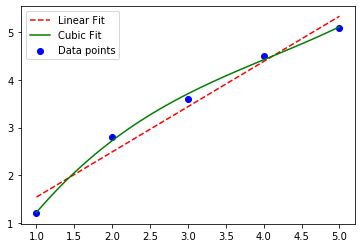

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Data Initialization
X = np.array([1, 2, 3, 4, 5])
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1])

def evaluate_fit(y_true, y_pred, label):
    mse = np.mean((y_true - y_pred)**2)
    ss_total = np.sum((y_true - np.mean(y_true))**2)
    ss_res = np.sum((y_true - y_pred)**2)
    r_squared = 1 - (ss_res / ss_total)
    print(f"{label}: MSE = {mse:.4f}, R-squared = {r_squared:.4f}")
    return mse, r_squared

# --- Part A: Linear vs Cubic Fit ---
print("--- Part A: Linear vs Cubic ---")
poly_lin = np.poly1d(np.polyfit(X, Y, 1))
poly_cubic = np.poly1d(np.polyfit(X, Y, 3))

mse_lin, r2_lin = evaluate_fit(Y, poly_lin(X), "Linear Fit")
mse_cub, r2_cub = evaluate_fit(Y, poly_cubic(X), "Cubic Fit")
print(f"Decision: {'Cubic' if r2_cub > r2_lin else 'Linear'} is the better fit.\n")

# --- Part B: Overfitting and Underfitting ---
print("--- Part B: Overfitting/Underfitting ---")
# Crank up 1 degree at a time until it overfits (Degree 4 is max for 5 points)
for d in range(3, 5):
    p = np.poly1d(np.polyfit(X, Y, d))
    evaluate_fit(Y, p(X), f"Cranking Up (Deg {d})")

# Crank down 1 degree at a time until it underfits (keep > 0)
for d in range(3, 0, -1):
    p = np.poly1d(np.polyfit(X, Y, d))
    evaluate_fit(Y, p(X), f"Cranking Down (Deg {d})")
print("")

# --- Part C: The Vandermonde Matrix ---
print("--- Part C: Vandermonde Implementation ---")
V = np.vander(X, 4) 
coeffs_vander, _, _, _ = np.linalg.lstsq(V, Y, rcond=None)
y_pred_vander = V.dot(coeffs_vander)
evaluate_fit(Y, y_pred_vander, "Vandermonde Cubic Fit")

# Visualization
plt.scatter(X, Y, color='blue', label='Data points')
X_smooth = np.linspace(X.min(), X.max(), 100)
plt.plot(X_smooth, poly_lin(X_smooth), 'r--', label='Linear Fit')
plt.plot(X_smooth, poly_cubic(X_smooth), 'g-', label='Cubic Fit')
plt.legend()
plt.show()